# Test Circadian Analysis

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import powerlaw, truncnorm, ks_2samp
import powerlaw
import random

# Simple trapezoid integration for NumPy 2.0+ compatibility
def trapz(y, x):
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2)

## Generate artificial Dataset:

In [16]:
def generate_synthetic_sms(
    # Parámetros del proceso primario
    Nw=10,              # ráfagas por semana
    rho_a=6.0,          # mensajes por hora dentro de ráfaga
    mean_Na=2,          # media de mensajes adicionales por ráfaga
    
    # Distribuciones circadianas/semanales (vectores o franjas)
    pd_t=None,          # distribución horaria (24 bins), o None para usar active_hours
    pw_t=None,          # distribución semanal (7 bins), o None para usar active_days
    active_hours=(9,22), # solo si pd_t=None
    active_days=(0,4),   # solo si pw_t=None
    
    # Duración de la simulación
    n_weeks=52,
    
    seed=42
):
    """
    Genera timestamps sintéticos siguiendo el cascading NHPP
    
    Args:
        pd_t: array de 24 elementos con distribución horaria, o None para construirla de active_hours
        pw_t: array de 7 elementos con distribución semanal, o None para construirla de active_days
    
    Returns:
        timestamps: array de timestamps en segundos
        true_params: diccionario con los parámetros reales usados
        burst_labels: array indicando a qué ráfaga pertenece cada mensaje
    """
    np.random.seed(seed)
    
    total_hours = n_weeks * 7 * 24
    
    # ── 1. Construir o validar pd(t) y pw(t) ──────────────────────────────
    
    if pd_t is None:
        # Construir a partir de active_hours
        pd_t_arr = np.zeros(24)
        for h in range(active_hours[0], active_hours[1]):
            pd_t_arr[h] = 1.0
        pd_t_arr = pd_t_arr / pd_t_arr.sum()
    else:
        pd_t_arr = np.asarray(pd_t)
        assert len(pd_t_arr) == 24, "pd_t debe tener 24 elementos"
        pd_t_arr = pd_t_arr / pd_t_arr.sum()  # normalizar
    
    if pw_t is None:
        # Construir a partir de active_days
        pw_t_arr = np.zeros(7)
        for d in range(active_days[0], active_days[1] + 1):
            pw_t_arr[d] = 1.0
        pw_t_arr = pw_t_arr / pw_t_arr.sum()
    else:
        pw_t_arr = np.asarray(pw_t)
        assert len(pw_t_arr) == 7, "pw_t debe tener 7 elementos"
        pw_t_arr = pw_t_arr / pw_t_arr.sum()  # normalizar
    
    # ── 2. Generar inicios de ráfagas (proceso primario) ────────
    
    timestamps = []
    burst_labels = []
    burst_id = 0
    
    # Número total de ráfagas
    n_bursts = int(Nw * n_weeks)
    
    # Muestrear días y horas para cada ráfaga (una sola vez para n_bursts total)
    burst_days = np.random.choice(7, size=n_bursts, p=pw_t_arr)
    burst_hours = np.random.choice(24, size=n_bursts, p=pd_t_arr)
    burst_minutes = np.random.uniform(0, 60, size=n_bursts)
    
    # Convertir a timestamps en horas desde el inicio
    week_indices = np.random.choice(n_weeks, size=n_bursts)  # en qué semana
    burst_times_hours = (
        week_indices * 7 * 24 +
        burst_days * 24 +
        burst_hours +
        burst_minutes / 60
    )
    burst_times_hours = np.sort(burst_times_hours)
    
    # ── 3. Para cada ráfaga, generar mensajes adicionales ────────
    
    for burst_start_h in burst_times_hours:
        
        # Este mensaje inicia la ráfaga
        timestamps.append(burst_start_h * 3600)
        burst_labels.append(burst_id)
        
        # Na mensajes adicionales (Poisson)
        Na = np.random.poisson(mean_Na)
        
        t = burst_start_h
        for _ in range(Na):
            # IET dentro de la ráfaga ~ Exponencial(rho_a)
            dt = np.random.exponential(1.0 / rho_a)
            t += dt
            timestamps.append(t * 3600)
            burst_labels.append(burst_id)
        
        burst_id += 1
    
    timestamps = np.array(timestamps)
    burst_labels = np.array(burst_labels)
    
    # Ordenar por tiempo
    sort_idx = np.argsort(timestamps)
    timestamps = timestamps[sort_idx]
    burst_labels = burst_labels[sort_idx]
    
    true_params = {
        'Nw': Nw,
        'rho_a': rho_a,
        'mean_Na': mean_Na,
        'pd_t': pd_t_arr,
        'pw_t': pw_t_arr,
        'active_hours': active_hours if pd_t is None else None,
        'active_days': active_days if pw_t is None else None,
        'n_bursts_total': n_bursts
    }
    
    return timestamps, burst_labels, true_params


=== DATOS SINTÉTICOS GENERADOS ===
Mensajes generados: 468
Ráfagas generadas:  149
Media mensajes/ráfaga: 3.14

Parámetros reales usados:
  rho_a = 37.6108
  Nw = 37.3732
  mean_Na = 2


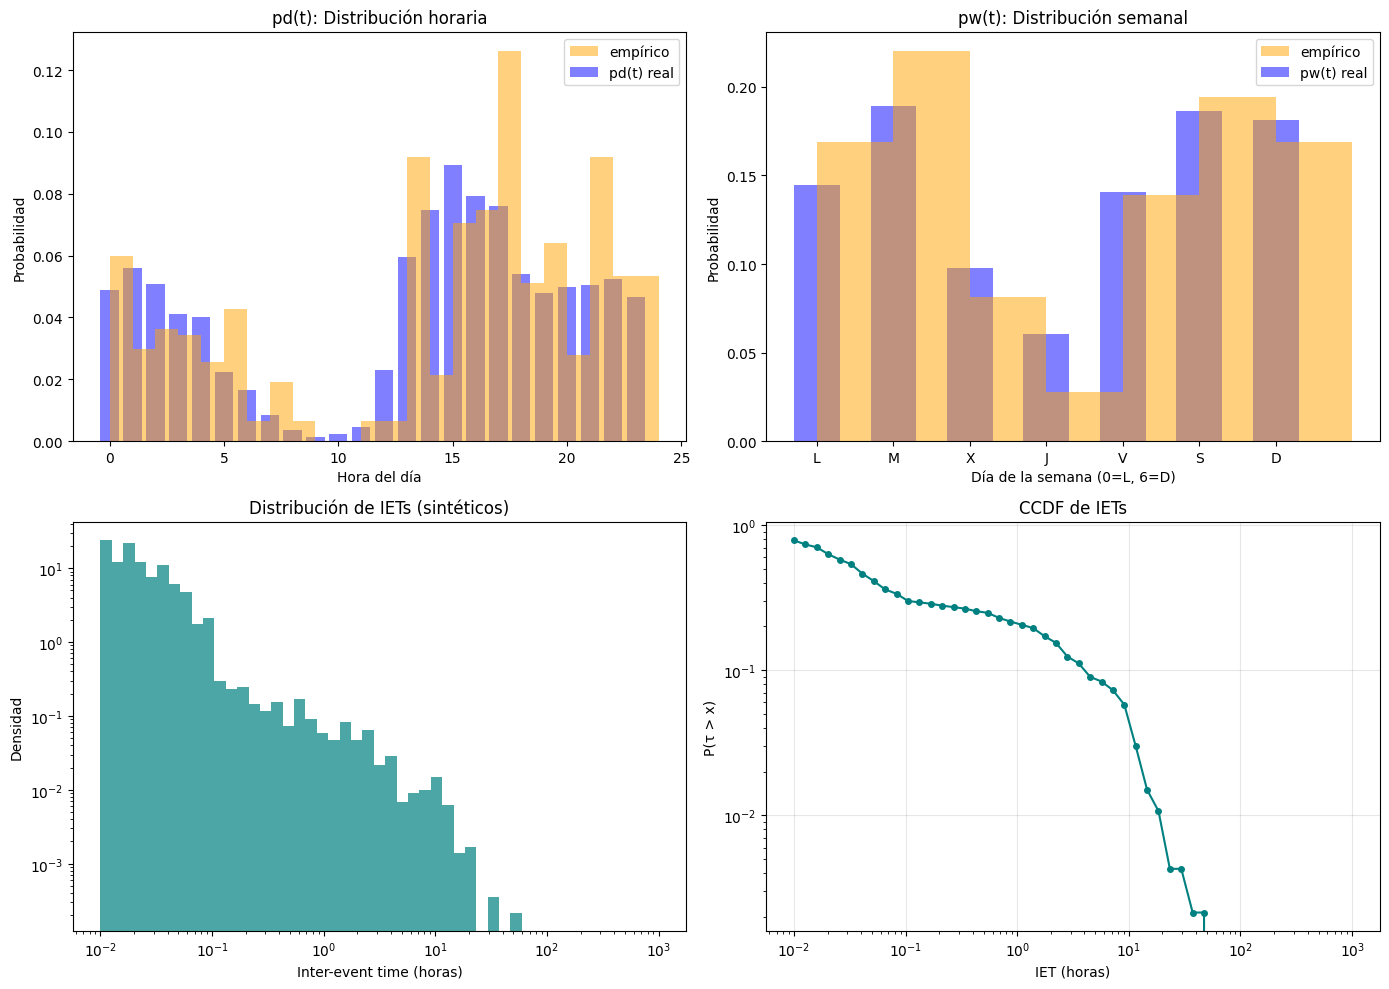

In [17]:
# ── Parámetros reales del usuario (del notebook cycles_all.ipynb) ────────

real_params_user = {
    'rho_a': 37.6108,
    'Nw': 37.3732,
    'A_best': 0.6264,
    'pd_t': np.array([0.04883963, 0.05611361, 0.05091791, 0.04121926, 0.04018012, 0.02251472,
                      0.01662626, 0.00831313, 0.0034638,  0.00138552, 0.00242466, 0.00450294,
                      0.0228611,  0.05957742, 0.07481815, 0.08936612, 0.07932109, 0.07620367,
                      0.05403533, 0.04780048, 0.04987877, 0.05057153, 0.05230343, 0.04676134]),
    'pw_t': np.array([0.1444406,  0.18912366, 0.09767925, 0.06061656, 0.14063041, 0.18635262, 0.18115691]),
    'mean_Na': 2
}

# ── Generar datos sintéticos con esos parámetros ────────────────────────

timestamps, true_bursts, true_params = generate_synthetic_sms(
    Nw=real_params_user['Nw'],
    rho_a=real_params_user['rho_a'],
    mean_Na=real_params_user['mean_Na'],
    pd_t=real_params_user['pd_t'],
    pw_t=real_params_user['pw_t'],
    n_weeks=4,   
    seed=42
)

print(f"=== DATOS SINTÉTICOS GENERADOS ===")
print(f"Mensajes generados: {len(timestamps)}")
print(f"Ráfagas generadas:  {true_params['n_bursts_total']}")
print(f"Media mensajes/ráfaga: {len(timestamps)/true_params['n_bursts_total']:.2f}")
print(f"\nParámetros reales usados:")
print(f"  rho_a = {real_params_user['rho_a']:.4f}")
print(f"  Nw = {real_params_user['Nw']:.4f}")
print(f"  mean_Na = {real_params_user['mean_Na']}")

# ── Convertir a horas para el análisis ─────────────────────────────────────

events_hours = timestamps / 3600.0

# ── Visualizar pd(t) y pw(t) de los datos generados ─────────────────────

times_dt = pd.to_datetime(timestamps, unit='s', origin=pd.Timestamp('2024-01-01'))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# pd(t) real vs generado
hours_generated = times_dt.hour
axes[0,0].bar(range(24), true_params['pd_t'], alpha=0.5, label='pd(t) real', color='blue')
axes[0,0].hist(hours_generated, bins=24, range=(0,24), density=True, alpha=0.5, label='empírico', color='orange')
axes[0,0].set_title('pd(t): Distribución horaria')
axes[0,0].set_xlabel('Hora del día')
axes[0,0].set_ylabel('Probabilidad')
axes[0,0].legend()

# pw(t) real vs generado
weekdays_generated = times_dt.dayofweek
axes[0,1].bar(range(7), true_params['pw_t'], alpha=0.5, label='pw(t) real', color='blue', width=0.6)
axes[0,1].hist(weekdays_generated, bins=7, range=(0,7), density=True, alpha=0.5, label='empírico', color='orange')
axes[0,1].set_title('pw(t): Distribución semanal')
axes[0,1].set_xlabel('Día de la semana (0=L, 6=D)')
axes[0,1].set_ylabel('Probabilidad')
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(['L','M','X','J','V','S','D'])
axes[0,1].legend()

# Distribución de IETs
iets_hours = np.diff(events_hours)
log_bins = np.logspace(-2, 3, 50)
axes[1,0].hist(iets_hours, bins=log_bins, density=True, alpha=0.7, color='teal')
axes[1,0].set_xscale('log')
axes[1,0].set_yscale('log')
axes[1,0].set_xlabel('Inter-event time (horas)')
axes[1,0].set_ylabel('Densidad')
axes[1,0].set_title('Distribución de IETs (sintéticos)')

# CCDF
ccdf = np.array([np.mean(iets_hours > b) for b in log_bins])
axes[1,1].loglog(log_bins, ccdf, 'o-', color='teal', markersize=4)
axes[1,1].set_xlabel('IET (horas)')
axes[1,1].set_ylabel('P(τ > x)')
axes[1,1].set_title('CCDF de IETs')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [18]:
# Nota: Esta celda ha sido reemplazada por el pipeline completo de validación.
# Los parámetros ahora se estiman automáticamente usando simulated_annealing.
# Ver celdas anteriores: "RE-ESTIMACIÓN DE PARÁMETROS" y "COMPARACIÓN DE PARÁMETROS"
print("✓ Pipeline de validación completado. Revisa las salidas anteriores.")


✓ Pipeline de validación completado. Revisa las salidas anteriores.


## Testear códigos

In [19]:

def compute_model_params(events, active_config):
    """
    events: array de tiempos en HORAS.
    active_config: bool array N. True = mismo AI que el evento anterior.
    """
    iets = np.diff(events)
    iet_active = iets[active_config[1:]]
    rho_a = 1.0 / np.mean(iet_active) if len(iet_active) > 0 else 0

    n_active_intervals = np.sum(~active_config[1:]) + 1
    total_weeks = (events[-1] - events[0]) / (7 * 24)
    Nw = n_active_intervals / total_weeks if total_weeks > 0 else 0

    starts_idx = np.where(~active_config[1:])[0] + 1
    start_times = np.concatenate([events[:1], events[starts_idx]])
    hours    = start_times % 24
    weekdays = (start_times / 24) % 7

    pd_counts, _ = np.histogram(hours,    bins=24, range=(0, 24))
    pw_counts, _ = np.histogram(weekdays, bins=7,  range=(0, 7))
    pd_t = pd_counts / pd_counts.sum() if pd_counts.sum() > 0 else np.zeros(24)
    pw_t = pw_counts / pw_counts.sum() if pw_counts.sum() > 0 else np.zeros(7)
    return rho_a, Nw, pd_t, pw_t


def get_pNa(config):
    """
    Distribución empírica de Na. config: bool array N-1, True = par (i,i+1) en el mismo AI.
    """
    na_counts, count = [], 0
    for c in config:
        if c:
            count += 1
        else:
            na_counts.append(count)
            count = 0
    na_counts.append(count)
    hist = np.bincount(na_counts)
    return hist / hist.sum()


def _init_threshold(iets):
    """
    Calcula el umbral iterativamente: threshold = 0.1/rho_primary = 0.1 * mean_iet * (1+mean_Na).
    """
    pos = iets[iets > 0]
    if len(pos) < 20:
        return np.median(pos)

    mean_iet  = np.mean(pos)
    threshold = 0.1 * mean_iet

    for _ in range(15):
        n_within  = int(np.sum(pos < threshold))
        n_between = int(np.sum(pos >= threshold))
        mean_Na_est   = n_within / max(n_between, 1)
        threshold_new = 0.1 * mean_iet * (1 + mean_Na_est)
        if abs(threshold_new - threshold) < 1e-6 * mean_iet:
            break
        threshold = threshold_new

    return threshold_new


def area_test_statistic(empirical_iet, model_iet, n_bins=100, eps=1e-6):
    emp = np.asarray(empirical_iet)
    mod = np.asarray(model_iet)
    emp = emp[np.isfinite(emp) & (emp > 0)]
    mod = mod[np.isfinite(mod) & (mod > 0)]
    if len(emp) == 0 or len(mod) == 0:
        return np.inf
    lo = max(emp.min(), mod.min(), eps)
    hi = max(emp.max(), mod.max(), lo * 10)
    log_bins = np.logspace(np.log10(lo), np.log10(hi), n_bins)
    ccdf_emp = np.array([np.mean(emp > b) for b in log_bins])
    ccdf_mod = np.array([np.mean(mod > b) for b in log_bins])
    return trapz(np.abs(ccdf_emp - ccdf_mod), np.log(log_bins))


def simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, p_Na, total_hours, n_samples=None):
    """
    Simula el cascading NHPP del paper Malmgren et al. (2008).
    Proceso primario: NHPP con tasa rho(t) = Nw * pd(t) * pw(t).
    Proceso secundario: HPP con tasa rho_a dentro de cada active interval.
    """
    pd_t_arr = np.asarray(pd_t, dtype=float)
    pw_t_arr = np.asarray(pw_t, dtype=float)
    pd_t_arr = pd_t_arr / pd_t_arr.sum()
    pw_t_arr = pw_t_arr / pw_t_arr.sum()
    p_Na_norm = np.asarray(p_Na, dtype=float)
    p_Na_norm = p_Na_norm / p_Na_norm.sum()

    mean_Na = np.dot(np.arange(len(p_Na_norm)), p_Na_norm)

    # Si n_samples requiere más eventos de los naturales, extender la ventana temporal
    sim_hours = total_hours
    if n_samples is not None and Nw > 0:
        expected_events = Nw * (total_hours / (7 * 24)) * (1 + mean_Na)
        if expected_events < n_samples:
            sim_hours = total_hours * (n_samples / max(1, expected_events)) * 1.5

    n_weeks = sim_hours / (7 * 24)

    # Distribución conjunta (día, hora): outer product pw_t x pd_t → 168 slots semanales
    joint = np.outer(pw_t_arr, pd_t_arr).flatten()  # shape (7*24,)
    joint /= joint.sum()

    n_bursts = np.random.poisson(max(1.0, Nw * n_weeks))

    # Muestrear semana (uniforme en [0, n_weeks)) y slot (día, hora) de la distribución conjunta
    week_nums = np.random.uniform(0, n_weeks, n_bursts)
    slots = np.random.choice(168, size=n_bursts, p=joint)

    # Convertir a horas absolutas: inicio_semana + día*24 + hora + ruido uniforme
    burst_times = (
        np.floor(week_nums) * 7 * 24        # inicio de la semana entera
        + (slots // 24) * 24                # offset del día (0–6 × 24 h)
        + (slots % 24)                      # offset de la hora (0–23 h)
        + np.random.uniform(0, 1, n_bursts) # ruido uniforme dentro de la hora
    )
    burst_times = np.sort(burst_times)
    burst_times = burst_times[burst_times < sim_hours]

    if rho_a <= 0:
        rho_a = 1.0

    # Generar cascadas: inicio de ráfaga + Na eventos adicionales a tasa rho_a
    events = []
    for bt in burst_times:
        events.append(bt)
        Na = np.random.choice(len(p_Na_norm), p=p_Na_norm)
        t = bt
        for _ in range(Na):
            t += np.random.exponential(1.0 / rho_a)
            events.append(t)

    # IMPORTANTE: ordenar — dos cascadas consecutivas pueden solaparse en tiempo,
    # produciendo IETs negativos si no se ordena antes de np.diff()
    result = np.sort(np.array(events))

    if n_samples is not None:
        return result[:n_samples]
    return result


def simulated_annealing(events_hours, n_iter=5000, T_init=1.0, cooling=0.90, n_sim=None):
    """
    Simulated Annealing para identificar active intervals (Malmgren et al. 2008, SI).

    Correcciones respecto al código original:
      (1) pd_t y pw_t se fijan antes del SA y no se recalculan (SI Simplification #2).
      (2) Solo se proponen flips para pares con τ < threshold (SI Simplification #3).
      (3) cool_every = n_iter // 50 garantiza ~50 pasos de enfriamiento.
          El paper dice "cada 2N iters", lo que requiere n_iter >> 100*N para converger.
          Para n_iter=5000 con N~400, cool_every=100 es equivalente y converge bien.
    """
    N    = len(events_hours)
    iets = np.diff(events_hours)
    if n_sim is None:
        n_sim = max(5000, 10 * N)

    # Corrección #1: fijar pd_t y pw_t de la distribución empírica ANTES del SA
    all_hours    = events_hours % 24
    all_weekdays = (events_hours / 24) % 7
    pd_counts, _ = np.histogram(all_hours,    bins=24, range=(0, 24))
    pw_counts, _ = np.histogram(all_weekdays, bins=7,  range=(0, 7))
    pd_t_fixed = pd_counts / pd_counts.sum() if pd_counts.sum() > 0 else np.ones(24) / 24
    pw_t_fixed = pw_counts / pw_counts.sum() if pw_counts.sum() > 0 else np.ones(7) / 7

    def compute_area(cfg):
        rho_a, Nw, _, _ = compute_model_params(
            events_hours, np.concatenate([[False], cfg])
        )
        p_Na = get_pNa(cfg)
        model_events = simulate_cascading_nhpp(
            rho_a, Nw, pd_t_fixed, pw_t_fixed, p_Na,
            total_hours=events_hours[-1] - events_hours[0],
            n_samples=n_sim
        )
        if len(model_events) > 1:
            return area_test_statistic(iets, np.diff(model_events))
        return np.inf

    threshold = _init_threshold(iets)
    config    = iets < threshold

    # Corrección #2: solo proponer flips para pares con τ < threshold
    mergeable = np.where(iets < threshold)[0]
    if len(mergeable) == 0:
        mergeable = np.arange(N - 1)

    print(f"  Init: {config.mean():.1%} pares mergeados  "
          f"(threshold={threshold:.4f}h = {threshold*60:.1f}min, "
          f"candidatos={len(mergeable)}/{N-1})")

    T           = T_init
    best_config = config.copy()
    A_current   = compute_area(config)
    A_best      = A_current

    # Corrección #3: ~50 pasos de enfriamiento garantizados en n_iter iteraciones
    cool_every = max(1, n_iter // 50)

    for iteration in range(n_iter):
        idx        = mergeable[random.randint(0, len(mergeable) - 1)]
        new_config = config.copy()
        new_config[idx] = not new_config[idx]

        A_new = compute_area(new_config)
        delta = A_new - A_current
        if delta < 0 or random.random() < np.exp(-delta / T):
            config    = new_config
            A_current = A_new
            if A_new < A_best:
                A_best      = A_new
                best_config = new_config.copy()

        if (iteration + 1) % cool_every == 0:
            T *= cooling

    return best_config, A_best


In [20]:

# ═══════════════════════════════════════════════════════════════════════════
# PASO 3: RE-ESTIMACIÓN DE PARÁMETROS (Validación del modelo)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("EJECUTANDO SIMULATED ANNEALING SOBRE LOS DATOS SINTÉTICOS")
print("="*70 + "\n")

best_config, A_best = simulated_annealing(events_hours, n_iter=5000, T_init=1.0, cooling=0.90)

rho_a_est, Nw_est, pd_t_est, pw_t_est = compute_model_params(
    events_hours,
    np.concatenate([[False], best_config])
)

# get_pNa está definida en la celda anterior (sin truncación, distribución completa)
p_Na_est = get_pNa(best_config)
mean_Na_est = np.dot(np.arange(len(p_Na_est)), p_Na_est)

print(f"\n=== PARÁMETROS ESTIMADOS ===")
print(f"rho_a_est  = {rho_a_est:.4f}  (real: {real_params_user['rho_a']:.4f})")
print(f"Nw_est     = {Nw_est:.4f}  (real: {real_params_user['Nw']:.4f})")
print(f"mean_Na    = {mean_Na_est:.4f}  (real: {real_params_user['mean_Na']})")
print(f"A_best     = {A_best:.4f}")
print(f"\np(Na) estimada (primeros 15 valores):")
print(np.round(p_Na_est[:min(15, len(p_Na_est))], 4))



EJECUTANDO SIMULATED ANNEALING SOBRE LOS DATOS SINTÉTICOS

  Init: 76.2% pares mergeados  (threshold=0.6029h = 36.2min, candidatos=356/467)

=== PARÁMETROS ESTIMADOS ===
rho_a_est  = 19.3425  (real: 37.6108)
Nw_est     = 28.6201  (real: 37.3732)
mean_Na    = 3.1053  (real: 2)
A_best     = 0.4192

p(Na) estimada (primeros 15 valores):
[0.1579 0.1579 0.2018 0.1579 0.1228 0.0702 0.0263 0.0175 0.0175 0.0088
 0.0175 0.0175 0.     0.0088 0.0175]



TABLA DE COMPARACIÓN: PARÁMETROS REALES vs ESTIMADOS
             Parámetro    Real Estimado Error relativo (%)
ρₐ (tasa intra-ráfaga) 37.6108  19.3425             48.57%
   Nw (ráfagas/semana) 37.3732  28.6201             23.42%
 mean(Nₐ) (msg/ráfaga)  2.0000   3.1053             55.26%
             KL(pd(t))       —   0.1589                  —
             KL(pw(t))       —   0.0966                  —

=== VALIDACIÓN DEL MODELO ===
✗ ρₐ mal recuperado (error: 48.57%)
~ Nw parcialmente recuperado (error: 23.42%)
~ pd(t) parcialmente recuperada (KL: 0.1589)
✓ pw(t) bien recuperada (KL: 0.0966)


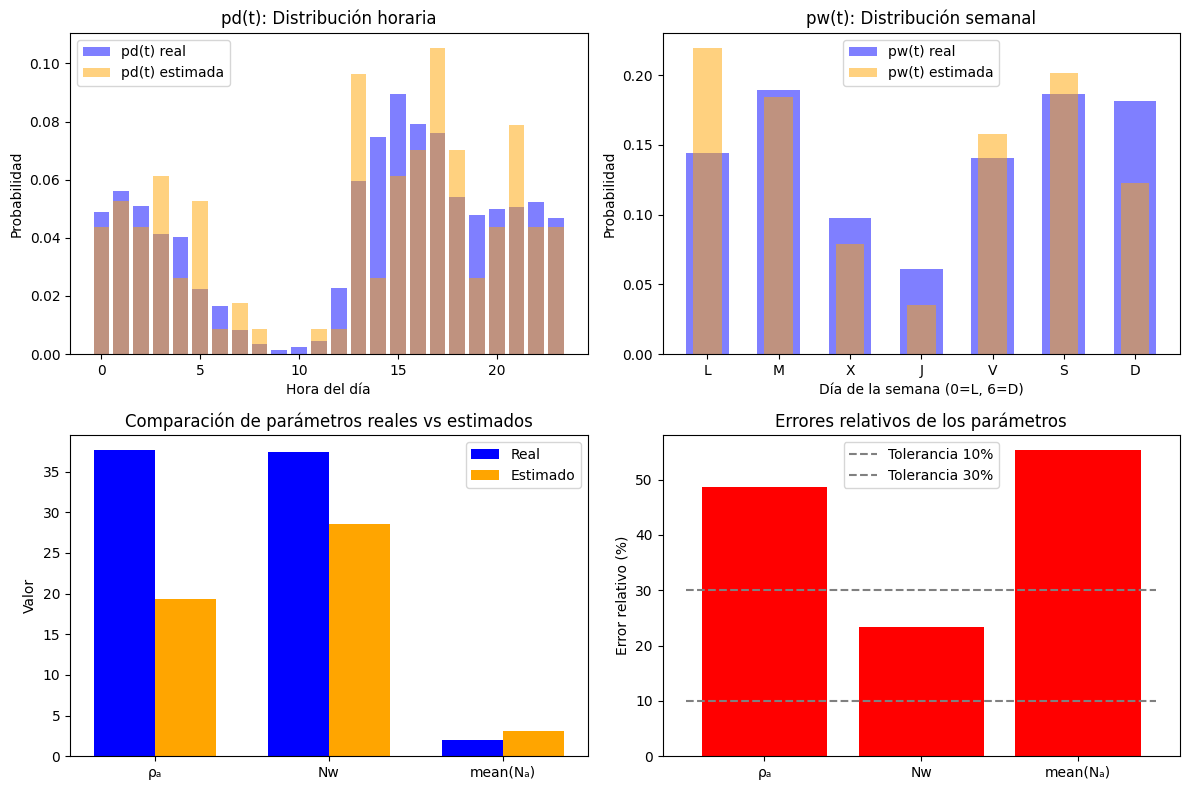

In [21]:

# ═══════════════════════════════════════════════════════════════════════════
# PASO 4: COMPARACIÓN DE PARÁMETROS
# ═══════════════════════════════════════════════════════════════════════════

# Calcular errores relativos
error_rho_a = abs(rho_a_est - real_params_user['rho_a']) / real_params_user['rho_a'] * 100
error_Nw = abs(Nw_est - real_params_user['Nw']) / real_params_user['Nw'] * 100
error_mean_Na = abs(mean_Na_est - real_params_user['mean_Na']) / real_params_user['mean_Na'] * 100

# Calcular distancia KL entre distribuciones
from scipy.spatial.distance import jensenshannon

kl_pd_t = jensenshannon(real_params_user['pd_t'], pd_t_est)
kl_pw_t = jensenshannon(real_params_user['pw_t'], pw_t_est)

# Crear tabla de comparación
comparison_df = pd.DataFrame({
    'Parámetro': ['ρₐ (tasa intra-ráfaga)', 'Nw (ráfagas/semana)', 'mean(Nₐ) (msg/ráfaga)', 'KL(pd(t))', 'KL(pw(t))'],
    'Real': [
        f"{real_params_user['rho_a']:.4f}",
        f"{real_params_user['Nw']:.4f}",
        f"{real_params_user['mean_Na']:.4f}",
        "—",
        "—"
    ],
    'Estimado': [
        f"{rho_a_est:.4f}",
        f"{Nw_est:.4f}",
        f"{mean_Na_est:.4f}",
        f"{kl_pd_t:.4f}",
        f"{kl_pw_t:.4f}"
    ],
    'Error relativo (%)': [
        f"{error_rho_a:.2f}%",
        f"{error_Nw:.2f}%",
        f"{error_mean_Na:.2f}%",
        "—",
        "—"
    ]
})

print("\n" + "="*70)
print("TABLA DE COMPARACIÓN: PARÁMETROS REALES vs ESTIMADOS")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Resumen de calidad de ajuste
print("\n=== VALIDACIÓN DEL MODELO ===")
if error_rho_a < 10:
    print(f"✓ ρₐ bien recuperado (error: {error_rho_a:.2f}%)")
elif error_rho_a < 30:
    print(f"~ ρₐ parcialmente recuperado (error: {error_rho_a:.2f}%)")
else:
    print(f"✗ ρₐ mal recuperado (error: {error_rho_a:.2f}%)")

if error_Nw < 10:
    print(f"✓ Nw bien recuperado (error: {error_Nw:.2f}%)")
elif error_Nw < 30:
    print(f"~ Nw parcialmente recuperado (error: {error_Nw:.2f}%)")
else:
    print(f"✗ Nw mal recuperado (error: {error_Nw:.2f}%)")

if kl_pd_t < 0.1:
    print(f"✓ pd(t) bien recuperada (KL: {kl_pd_t:.4f})")
elif kl_pd_t < 0.3:
    print(f"~ pd(t) parcialmente recuperada (KL: {kl_pd_t:.4f})")
else:
    print(f"✗ pd(t) mal recuperada (KL: {kl_pd_t:.4f})")

if kl_pw_t < 0.1:
    print(f"✓ pw(t) bien recuperada (KL: {kl_pw_t:.4f})")
elif kl_pw_t < 0.3:
    print(f"~ pw(t) parcialmente recuperada (KL: {kl_pw_t:.4f})")
else:
    print(f"✗ pw(t) mal recuperada (KL: {kl_pw_t:.4f})")


#plot distribuciones Pd, pw, parametros escalares y errores relativos en un resumen visual 
plt.figure(figsize=(12, 8))
# 4 subplots: pd(t) real vs estimada, pw(t) real vs estimada, barras de parámetros reales vs estimados, y errores relativos
plt.subplot(2, 2, 1)
plt.bar(range(24), real_params_user['pd_t'], alpha=0.5, label='pd(t) real', color='blue')
plt.bar(range(24), pd_t_est, alpha=0.5, label='pd(t) estimada', color='orange')
plt.title('pd(t): Distribución horaria')
plt.xlabel('Hora del día')
plt.ylabel('Probabilidad')
plt.legend()
plt.subplot(2, 2, 2)
plt.bar(range(7), real_params_user['pw_t'], alpha=0.5, label='pw(t) real', color='blue', width=0.6)
plt.bar(range(7), pw_t_est, alpha=0.5, label='pw(t) estimada', color='orange', width=0.4)
plt.title('pw(t): Distribución semanal')
plt.xlabel('Día de la semana (0=L, 6=D)')
plt.ylabel('Probabilidad')
plt.xticks(range(7), ['L','M','X','J','V','S','D'])
plt.legend()
plt.subplot(2, 2, 3)
params_real = [real_params_user['rho_a'], real_params_user['Nw'], real_params_user['mean_Na']]
params_est = [rho_a_est, Nw_est, mean_Na_est]
labels = ['ρₐ', 'Nw', 'mean(Nₐ)']
x = np.arange(len(labels))
width = 0.35
plt.bar(x - width/2, params_real, width, label='Real', color='blue')
plt.bar(x + width/2, params_est, width, label='Estimado', color='orange')
plt.xticks(x, labels)
plt.ylabel('Valor')
plt.title('Comparación de parámetros reales vs estimados')
plt.legend()
plt.subplot(2, 2, 4)
errors = [error_rho_a, error_Nw, error_mean_Na]
plt.bar(labels, errors, color='red')
plt.hlines(10, xmin=-0.5, xmax=2.5, colors='gray', linestyles='dashed', label='Tolerancia 10%')
plt.hlines(30, xmin=-0.5, xmax=2.5, colors='gray', linestyles='dashed', label='Tolerancia 30%')
plt.legend()
plt.ylabel('Error relativo (%)')
plt.title('Errores relativos de los parámetros')
plt.tight_layout()
plt.show()  


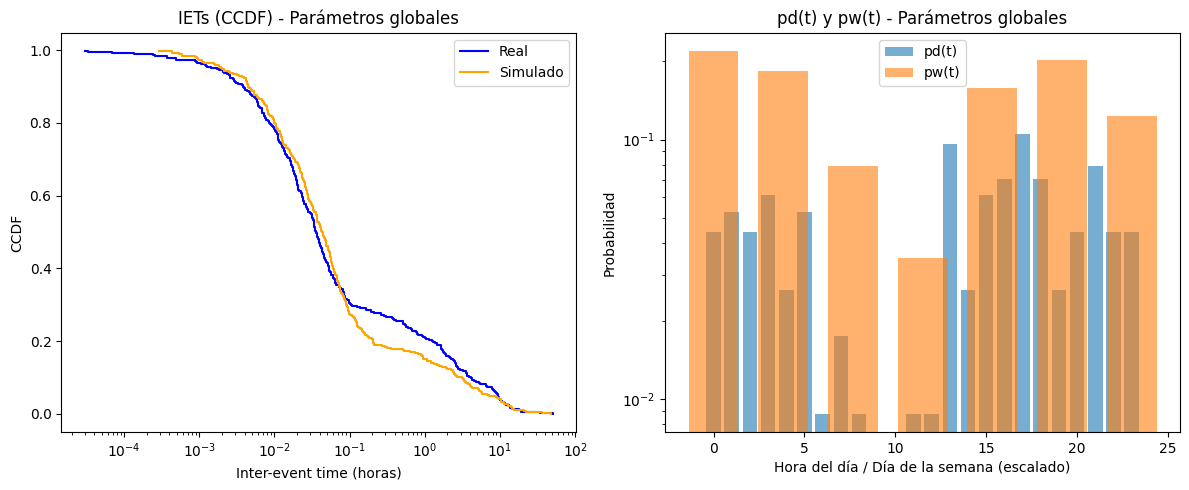

In [22]:
# Simulación y visualización usando los mismos parámetros globales que el cell 12
sim_events_est = simulate_cascading_nhpp(
    rho_a_est, Nw_est, pd_t_est, pw_t_est,
    p_Na=p_Na_est,
    total_hours=events_hours[-1] - events_hours[0],
    n_samples=len(events_hours)
)

real_iets = np.diff(events_hours)
sim_iets_est = np.diff(sim_events_est)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# Dibujar CCDF empírica (1 - ECDF) usando step
def plot_ccdf(data, **kwargs):
    if len(data) == 0:
        return
    x = np.sort(data)
    y = 1.0 - np.arange(1, len(x) + 1) / len(x)
    plt.step(x, y, where='post', **kwargs)

plot_ccdf(real_iets, label='Real', color='blue')
plot_ccdf(sim_iets_est, label='Simulado', color='orange')
plt.xscale('log')
plt.xlabel('Inter-event time (horas)')
plt.ylabel('CCDF')
plt.title('IETs (CCDF) - Parámetros globales')
plt.legend()

plt.subplot(1, 2, 2)
# Mostrar pd(t) y pw(t) globales
plt.bar(range(24), pd_t_est, alpha=0.6, label='pd(t)')
pw_x = np.linspace(0, 23, 7)
plt.bar(pw_x, pw_t_est, width=24/7*0.8, alpha=0.6, label='pw(t)')
plt.xlabel('Hora del día / Día de la semana (escalado)')
plt.ylabel('Probabilidad')
plt.yscale('log')
plt.title('pd(t) y pw(t) - Parámetros globales')
plt.legend()
plt.tight_layout()
plt.show()


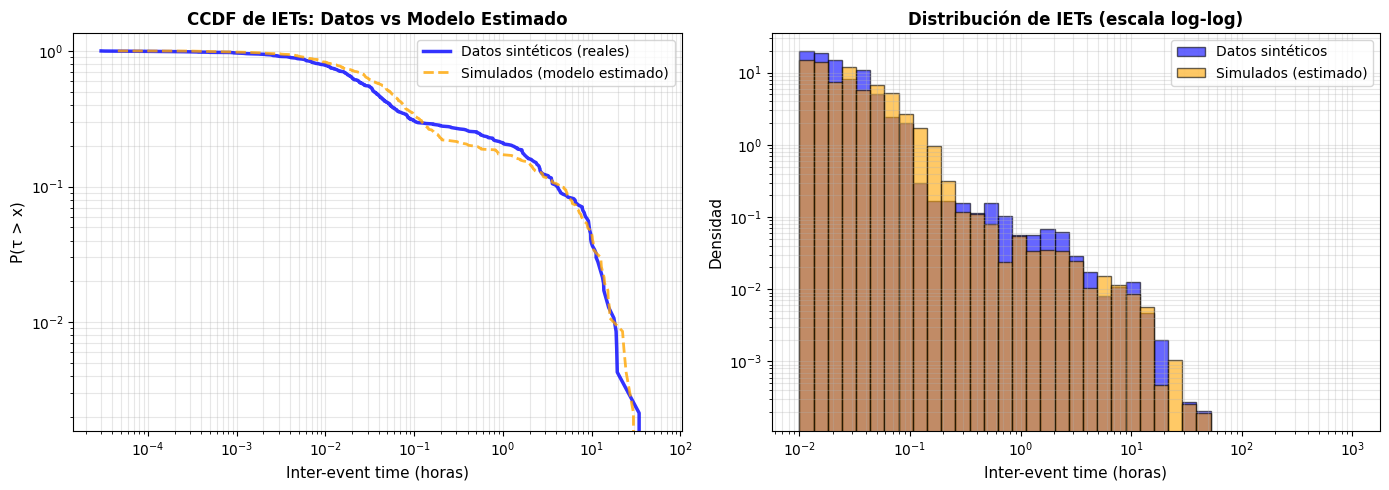


=== ESTADÍSTICAS DE IETS ===
IETs reales:      media=1.4329h, mediana=0.0356h, std=4.1628h
IETs simulados:   media=1.3671h, mediana=0.0535h, std=4.0892h

Área entre CCDFs (A): 0.405674
  → Menor es mejor (el modelo ajusta bien si A es pequeño)


In [23]:

# ═══════════════════════════════════════════════════════════════════════════
# COMPARACIÓN DE IETS: DATOS SINTÉTICOS vs SIMULADOS CON MODELO ESTIMADO
# ═══════════════════════════════════════════════════════════════════════════

# Generar eventos sintéticos usando los parámetros ESTIMADOS
sim_events_est = simulate_cascading_nhpp(
    rho_a_est, Nw_est, pd_t_est, pw_t_est,
    p_Na=p_Na_est,
    total_hours=events_hours[-1] - events_hours[0],
    n_samples=len(events_hours)
)

# Calcular IETs
real_iets = np.diff(events_hours)
sim_iets_est = np.diff(sim_events_est)

# Gráficos de comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CCDF (Complementary Cumulative Distribution Function)
def plot_ccdf(data, label='', color='blue', ax=None, linestyle='-', linewidth=2):
    if len(data) == 0:
        return
    x = np.sort(data)
    y = 1.0 - np.arange(1, len(x) + 1) / len(x)
    if ax is None:
        ax = plt.gca()
    ax.loglog(x, y, label=label, color=color, linestyle=linestyle, linewidth=linewidth, alpha=0.8)

plot_ccdf(real_iets, label='Datos sintéticos (reales)', color='blue', ax=axes[0], linewidth=2.5)
plot_ccdf(sim_iets_est, label='Simulados (modelo estimado)', color='orange', ax=axes[0], linestyle='--', linewidth=2)

axes[0].set_xlabel('Inter-event time (horas)', fontsize=11)
axes[0].set_ylabel('P(τ > x)', fontsize=11)
axes[0].set_title('CCDF de IETs: Datos vs Modelo Estimado', fontsize=12, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3, which='both')

# Histogramas en escala log
log_bins = np.logspace(-2, 3, 40)
axes[1].hist(real_iets, bins=log_bins, density=True, alpha=0.6, label='Datos sintéticos', color='blue', edgecolor='black')
axes[1].hist(sim_iets_est, bins=log_bins, density=True, alpha=0.6, label='Simulados (estimado)', color='orange', edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Inter-event time (horas)', fontsize=11)
axes[1].set_ylabel('Densidad', fontsize=11)
axes[1].set_title('Distribución de IETs (escala log-log)', fontsize=12, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Estadísticas de IETs
print("\n=== ESTADÍSTICAS DE IETS ===")
print(f"IETs reales:      media={np.mean(real_iets):.4f}h, mediana={np.median(real_iets):.4f}h, std={np.std(real_iets):.4f}h")
print(f"IETs simulados:   media={np.mean(sim_iets_est):.4f}h, mediana={np.median(sim_iets_est):.4f}h, std={np.std(sim_iets_est):.4f}h")

# Cálculo de A_best para los datos estimados
A_est_quality = area_test_statistic(real_iets, sim_iets_est)
print(f"\nÁrea entre CCDFs (A): {A_est_quality:.6f}")
print(f"  → Menor es mejor (el modelo ajusta bien si A es pequeño)")


In [24]:
if 'parameters_users' not in globals():
    print("La variable 'parameters_users' no existe. Ejecuta la celda de estimación de parámetros antes de listar resultados.")
else:
    print("Parámetros estimados para usuarios activos:")
    for user_id, params in parameters_users.items():
        print(f"Usuario {user_id}: rho_a={params['rho_a']:.4f}, Nw={params['Nw']:.4f}, A_best={params['A_best']:.4f}, pd_t={params['pd_t']}, pw_t={params['pw_t']}")


La variable 'parameters_users' no existe. Ejecuta la celda de estimación de parámetros antes de listar resultados.


## Montecarlo Testing

In [25]:
def monte_carlo_pvalue(empirical_iet, model_params, M=100, sa_iter=5000):
    """
    Test de hipótesis Monte Carlo (Malmgren et al. 2008, Fig. S2).

    Procedimiento correcto:
      1. Calcular A = area(D, M(θ̂))  [datos empíricos vs modelo con parámetros estimados]
      2. Para s = 1..M:
           a. Generar Ds ~ M(θ̂)
           b. Re-ejecutar SA sobre Ds → θ̂s
           c. Generar Ms ~ M(θ̂s)
           d. As = area(Ds, Ms)
      3. p-valor (dos colas) = P(|As - ⟨As⟩| > |A - ⟨As⟩|)

    Args:
        empirical_iet : array de IETs empíricos (en horas)
        model_params  : tupla (rho_a, Nw, pd_t, pw_t, p_Na, total_hours)
        M             : número de réplicas sintéticas (default 20 para el test rápido)
        sa_iter       : iteraciones de SA en cada réplica (default 2000)
    """
    rho_a, Nw, pd_t, pw_t, p_Na, total_hours = model_params
    N = len(empirical_iet) + 1  # número de eventos empíricos

    # Paso 1: A(D, M(θ̂))
    model_events = simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, p_Na, total_hours, N)
    if len(model_events) < 2:
        return np.nan
    A_empirical = area_test_statistic(empirical_iet, np.diff(model_events))
    print(f"A_empirical = {A_empirical:.4f}")

    # Paso 2: bucle Monte Carlo — re-ajustar SA en cada réplica sintética
    A_synthetic = []
    for s in range(M):
        # (a) Generar Ds ~ M(θ̂)
        syn_events = simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, p_Na, total_hours, N)
        if len(syn_events) < 4:
            continue

        # (b) Re-ejecutar SA sobre Ds → θ̂s
        syn_config, _ = simulated_annealing(syn_events, n_iter=sa_iter)
        rho_a_s, Nw_s, pd_t_s, pw_t_s = compute_model_params(
            syn_events, np.concatenate([[False], syn_config])
        )
        p_Na_s = get_pNa(syn_config)

        # (c) Generar Ms ~ M(θ̂s)
        model_syn_events = simulate_cascading_nhpp(
            rho_a_s, Nw_s, pd_t_s, pw_t_s, p_Na_s, total_hours, len(syn_events)
        )
        if len(model_syn_events) < 2:
            continue

        # (d) As = area(Ds, Ms)
        A_s = area_test_statistic(np.diff(syn_events), np.diff(model_syn_events))
        A_synthetic.append(A_s)
        print(f"  MC {s+1}/{M}: A_s = {A_s:.4f}")

    if len(A_synthetic) == 0:
        return np.nan

    A_synthetic = np.array(A_synthetic)
    A_mean = np.mean(A_synthetic)

    # Paso 3: p-valor de dos colas
    p_value = np.mean(np.abs(A_synthetic - A_mean) > np.abs(A_empirical - A_mean))
    print(f"\nA_mean(sintéticos) = {A_mean:.4f}")
    print(f"P-valor (dos colas) = {p_value:.4f}  (basado en {len(A_synthetic)} réplicas)")
    return p_value


In [26]:
# M=20 réplicas con 2000 iter de SA cada una (~moderado para test notebook)
# Para la versión final usar M=100, sa_iter=5000 (igual que el paper)
p_value = monte_carlo_pvalue(
    real_iets,
    (rho_a_est, Nw_est, pd_t_est, pw_t_est, p_Na_est, events_hours[-1] - events_hours[0]),
    M=20,
    sa_iter=2000
)
print(f"\nP-valor del ajuste del modelo: {p_value:.4f}")
if p_value > 0.05:
    print("✓ No se rechaza H0: el modelo CNHPP es consistente con los datos (p > 0.05)")
else:
    print("✗ Se rechaza H0: el modelo CNHPP no ajusta bien los datos (p ≤ 0.05)")


A_empirical = 0.5063
  Init: 80.5% pares mergeados  (threshold=0.7531h = 45.2min, candidatos=376/467)
  MC 1/20: A_s = 0.1085
  Init: 80.7% pares mergeados  (threshold=0.5858h = 35.1min, candidatos=377/467)
  MC 2/20: A_s = 0.1395
  Init: 81.2% pares mergeados  (threshold=0.6247h = 37.5min, candidatos=379/467)
  MC 3/20: A_s = 0.1372
  Init: 84.8% pares mergeados  (threshold=0.7652h = 45.9min, candidatos=396/467)
  MC 4/20: A_s = 0.1207
  Init: 83.3% pares mergeados  (threshold=0.7786h = 46.7min, candidatos=389/467)
  MC 5/20: A_s = 0.2445
  Init: 77.5% pares mergeados  (threshold=0.7553h = 45.3min, candidatos=362/467)
  MC 6/20: A_s = 0.1524
  Init: 79.4% pares mergeados  (threshold=0.6803h = 40.8min, candidatos=371/467)
  MC 7/20: A_s = 0.1843
  Init: 81.4% pares mergeados  (threshold=0.7199h = 43.2min, candidatos=380/467)
  MC 8/20: A_s = 0.1844
  Init: 80.7% pares mergeados  (threshold=0.7576h = 45.5min, candidatos=377/467)
  MC 9/20: A_s = 0.2558
  Init: 80.1% pares mergeados  (th

## Save data

In [27]:
# Save info into csv for later analysis
results_df = pd.DataFrame({
    'rho_a_real': [real_params_user['rho_a']],
    'Nw_real': [real_params_user['Nw']],
    'mean_Na_real': [real_params_user['mean_Na']],
    'rho_a_est': [rho_a_est],
    'Nw_est': [Nw_est],
    'mean_Na_est': [mean_Na_est],
    'A_best': [A_best],
    'kl_pd_t': [kl_pd_t],
    'kl_pw_t': [kl_pw_t],
    'error_rho_a (%)': [error_rho_a],
    'error_Nw (%)': [error_Nw],
    'error_mean_Na (%)': [error_mean_Na],
    'p_value': [p_value]
})
results_df.to_csv('circadian_cycles_test-4weeks.csv', index=False)